In [76]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import datetime
import pytz
NYC_tz = pytz.timezone("America/New_York") 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [77]:
import sys
sys.path.append("../../")

import rateslib as rl
import QuantLib as ql

from Query.IRSwaps.IRSwapQuery import IRSwapQuery 
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapValue import IRSwapValue

In [78]:
curve_mdp = IRSwapsMDP(source="BARCHART_STIRF-RL")

In [81]:
ts = NYC_tz.localize(datetime.datetime(2026, 4, 10, 17, 00))
curve = "USD-SOFR-1D-Q16STIRT"

curve_handle = curve_mdp.get_pricer(request=dict(curve_name=curve, timestamp=ts))
curve_handle

RLIRSwapCurve(_rl_curve_id='USD-SOFR-1D', _rl_curve_handle=<rl.Curve:USD-SOFR-1D at 0x19811a69640>, _meta_data={'timestamp': datetime.datetime(2026, 4, 10, 17, 0, tzinfo=<DstTzInfo 'America/New_York' EDT-1 day, 20:00:00 DST>), 'id': 'BARCHART_STIRF-RL-USD-SOFR-1D-Q16STIRT-2026-04-10 17:00:00-04:00', 'requested_curve_name': 'USD-SOFR-1D-Q16STIRT', 'curve_name': 'USD-SOFR-1D-Q16STIRT'})

In [71]:
risk_model_tenors = [
	# "fomc_1",
	# "fomc_2",
	# "fomc_3",
	# "fomc_4",
	# "fomc_5",
	# "fomc_6",
	# "fomc_7",
	
	"IMM_1xIMM_2",
    "IMM_2xIMM_3",
    "IMM_3xIMM_4",
    "IMM_4xIMM_5",
    "IMM_5xIMM_6",
    "IMM_6xIMM_7",
    "IMM_7xIMM_8",
    "IMM_8xIMM_9",
    "IMM_9xIMM_10",
    "IMM_10xIMM_11",
    "IMM_11xIMM_12",
    "IMM_12xIMM_13",
    
	# "IMM_13xIMM_14",
    # "IMM_14xIMM_15",
    # "IMM_15xIMM_16",
    # "IMM_16xIMM_17",
	# "IMM_17xIMM_18",
    # "IMM_18xIMM_19",
    # "IMM_19xIMM_20",
    # "IMM_20xIMM_21",
]
rl_risk_instruments = {}
for t in risk_model_tenors:
    outright_query = IRSwapQuery(curve=curve, tenor=t).resolve_query(ts, pricer_or_curve=curve_handle)
    outright_pkg, _ = outright_query.resolve_package(pricer_or_curve=curve_handle)
    rl_risk_instruments[t] = outright_pkg[0]

rl_risk_solver = rl.Solver(
    curves=[curve_handle.handle()],
    instruments=rl_risk_instruments.values(),
    instrument_labels=rl_risk_instruments.keys(),
    s=[r.rate().real for r in rl_risk_instruments.values()],
    id=curve_handle.id(),
    func_tol=1e-8,
    conv_tol=1e-10,
)

SUCCESS: `func_tol` reached after 0 iterations (levenberg_marquardt), `f_val`: 0.0, `time`: 0.0008s


In [72]:
risk = 100_000

tenor = "IMM_1xIMM_2"
query = IRSwapQuery(curve=curve, tenor=tenor, structure_kwargs={"bpv": risk}).resolve_query(
    ts, pricer_or_curve=curve_handle
)
pkg, rws = query.resolve_package(pricer_or_curve=curve_handle)

vmap = query.build_value_map(pricer_or_curve=curve_handle, package=pkg, risk_weights=rws)
for v in [IRSwapValue.RATE, IRSwapValue.NPV, IRSwapValue.NOTIONAL, IRSwapValue.PV01]:
    print(v.name, vmap.apply(value=v))

print(curve_handle.effective_date(pkg[0]))
print(curve_handle.maturity_date(pkg[0]))
# print(vmap.apply(value=IRSwapValue.CARRY_BPS_RUNNING, **{"horizon": "3m"}))
print(vmap.apply(value=IRSwapValue.ROLL_BPS_RUNNING, **{"horizon": "1m"}))

display(rl.Portfolio(pkg).delta(solver=rl_risk_solver).style.format("{:_.0f}"))

RATE 3.672916258111937
NPV 0.0
NOTIONAL 4021314945.7711306
PV01 100000.0
2026-06-17 00:00:00
2026-09-16 00:00:00
0.4617812078387684


(<Figure size 1200x800 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x1981587d590>])

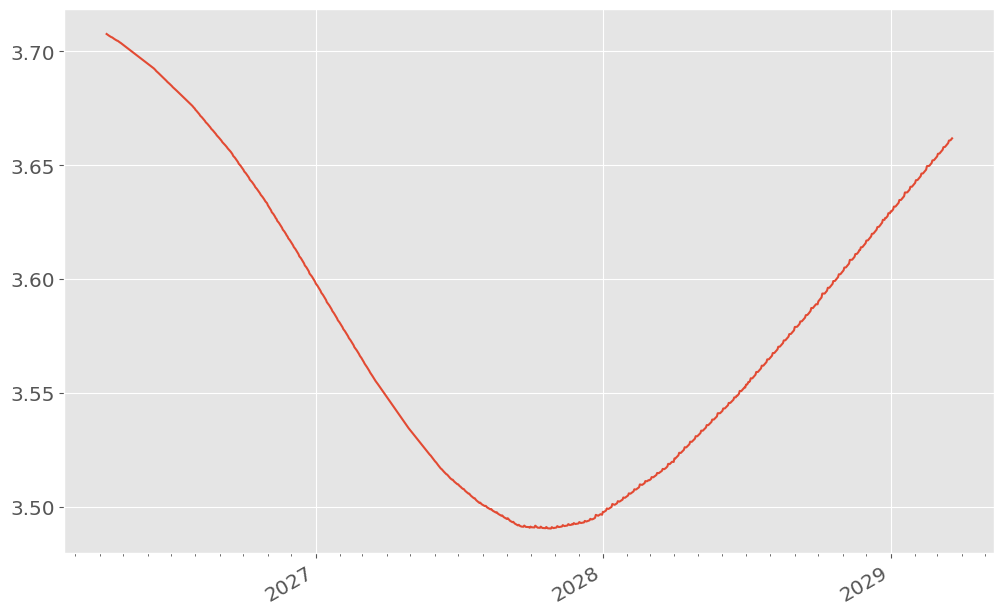

In [84]:
curve_handle.handle().plot("1y")

# queries = [
#     # IRSwapQuery(curve=curve, tenor="IMM_H26xIMM_M26", structure_kwargs={"bpv": risk}).resolve_query(ts, pricer_or_curve=curve_handle),
#     IRSwapQuery(curve=curve, tenor="IMM_M26xIMM_U26", structure_kwargs={"bpv": risk}).resolve_query(ts, pricer_or_curve=curve_handle),
#     # IRSwapQuery(curve=curve, tenor="IMM_U26xIMM_Z26", structure_kwargs={"bpv": risk}).resolve_query(ts, pricer_or_curve=curve_handle),
#     IRSwapQuery(curve=curve, tenor="IMM_Z26xIMM_H27", structure_kwargs={"bpv": risk}).resolve_query(ts, pricer_or_curve=curve_handle),
#     # IRSwapQuery(curve=curve, tenor="IMM_H27xIMM_M27", structure_kwargs={"bpv": risk}).resolve_query(ts, pricer_or_curve=curve_handle),
#     IRSwapQuery(curve=curve, tenor="IMM_M27xIMM_U27", structure_kwargs={"bpv": risk}).resolve_query(ts, pricer_or_curve=curve_handle),
#     # IRSwapQuery(curve=curve, tenor="IMM_U27xIMM_Z27", structure_kwargs={"bpv": risk}).resolve_query(ts, pricer_or_curve=curve_handle),
#     IRSwapQuery(curve=curve, tenor="IMM_Z27xIMM_H28", structure_kwargs={"bpv": risk}).resolve_query(ts, pricer_or_curve=curve_handle),
#     # IRSwapQuery(curve=curve, tenor="IMM_H28xIMM_M28", structure_kwargs={"bpv": risk}).resolve_query(ts, pricer_or_curve=curve_handle),
#     IRSwapQuery(curve=curve, tenor="IMM_M28xIMM_U28", structure_kwargs={"bpv": risk}).resolve_query(ts, pricer_or_curve=curve_handle),
#     # IRSwapQuery(curve=curve, tenor="IMM_U28xIMM_Z28", structure_kwargs={"bpv": risk}).resolve_query(ts, pricer_or_curve=curve_handle),
#     IRSwapQuery(curve=curve, tenor="IMM_Z28xIMM_H29", structure_kwargs={"bpv": risk}).resolve_query(ts, pricer_or_curve=curve_handle),
#     # IRSwapQuery(curve=curve, tenor="IMM_H29xIMM_M29", structure_kwargs={"bpv": risk}).resolve_query(ts, pricer_or_curve=curve_handle),
# ]

# rl_spots = []
# for q in queries:
#     pkg, _ = q.resolve_package(pricer_or_curve=curve_handle)
#     print(f"{q.col_name()}, {pkg[0].rate().real}")

#     rl_spots.append(pkg[0])

# x = [s.__dict__["kwargs"]["termination"] for s in rl_spots]
# y = [s.rate().real for s in rl_spots]

# fig = go.Figure()
# fig.add_trace(go.Scatter(x=x, y=y, mode="lines", name="1D"))
# tick_vals = [pd.Timestamp(t).tz_localize(None) for t in x]
# tick_text = [pd.Timestamp(t).strftime("%Y-%m-%d") for t in tick_vals]
# fig.update_layout(
#     title=f"{curve_handle.meta()["id"]} | {curve_handle.meta()["timestamp"]} | spot term curve",
#     template="plotly_dark",
#     margin=dict(l=40, r=20, t=60, b=80),
#     xaxis=dict(tickmode="array", tickvals=tick_vals, ticktext=tick_text, tickangle=45, showgrid=True),
#     height=550,
#     yaxis=dict(showgrid=True),
# )
# fig.update_xaxes(
#     showspikes=True,
#     spikecolor="white",
#     spikesnap="cursor",
#     spikemode="across",
#     showgrid=True,
# )
# fig.update_yaxes(
#     showspikes=True,
#     spikecolor="white",
#     spikesnap="cursor",
#     spikethickness=0.5,
#     showgrid=True,
# )
# fig.show()